# Project 3: Unsupervised Learning — Customer Segmentation

## DecodeLabs Data Science Internship

### Objective

The objective of this project is to discover meaningful customer segments from unlabeled retail and customer behavior data using unsupervised learning techniques.

The project will apply:

- Data preprocessing and feature selection
- Feature standardization
- Principal Component Analysis (PCA)
- K-Means clustering
- Elbow Method
- Silhouette Score
- Cluster profiling
- Business-oriented customer personas

The final clusters will be interpreted to identify distinct customer behavior patterns and translate the mathematical results into actionable business insights.

## 1. Import Required Libraries

The following libraries are used for data manipulation, visualization, preprocessing, dimensionality reduction, clustering, and cluster evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Load Dataset

The customer dataset is loaded from the project's dedicated `data` directory.

The dataset is tab-separated, so the tab character (`\t`) is specified as the delimiter.

In [2]:
df = pd.read_csv(r"marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 3. Initial Dataset Inspection

Before preprocessing, the dataset is inspected to understand its dimensions, available variables, data types, and general structure.

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst Five Rows:")
display(df.head())

Dataset Shape: (2240, 29)

Column Names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Data Types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
N

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Dataset Structure

The dataset contains customer demographic information, household characteristics, purchasing behavior, campaign responses, and engagement-related variables.

These variables provide a suitable foundation for discovering customer segments through unsupervised learning.

## 4. Data Quality Assessment

Before applying feature engineering, dimensionality reduction, or clustering, the dataset must be checked for data quality issues.

The following checks will be performed:

- Missing values
- Duplicate records
- Data types
- Unique values
- Potential inconsistencies

This ensures that the clustering algorithm receives reliable and appropriately prepared data.

In [4]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing Values:")
display(missing_values[missing_values > 0])

Missing Values:


Income    24
dtype: int64

### Duplicate Records

Duplicate customer records can distort clustering results by giving identical observations additional influence.

Therefore, duplicate rows are checked before proceeding with feature preparation.

In [5]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Statistical Summary

A statistical summary is generated for the numerical variables to understand their distributions, ranges, and potential scale differences.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


### Categorical Variables

The unique values of categorical variables are inspected to identify inconsistent or unexpected categories before encoding.

In [7]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


Education:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital_Status:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Dt_Customer:
Dt_Customer
31-08-2012    12
12-09-2012    11
14-02-2013    11
12-05-2014    11
20-08-2013    10
              ..
05-08-2012     1
18-11-2012     1
25-05-2013     1
14-04-2013     1
09-01-2014     1
Name: count, Length: 663, dtype: int64


## 4. Data Cleaning and Feature Engineering

Before applying clustering algorithms, the dataset must be cleaned and transformed into a suitable numerical representation.

The following preprocessing steps will be performed:

- Handle missing values in the `Income` variable.
- Convert the customer date variable into a usable datetime format.
- Create meaningful demographic and purchasing features.
- Aggregate purchasing behavior into total spending and purchase frequency.
- Create campaign-related features.
- Remove identifiers and constant variables that do not provide useful information for clustering.

These transformations are intended to improve the quality and interpretability of the customer segmentation results.

### 4.1 Creating a Clean Working Dataset

A separate copy of the original dataset is created so that the raw data remains unchanged throughout the analysis.

In [8]:
# Create a working copy of the original dataset
df_clean = df.copy()

# Display the initial shape
print("Initial dataset shape:", df_clean.shape)

Initial dataset shape: (2240, 29)


### 4.2 Handling Missing Values

The `Income` variable contains 24 missing observations.

Because income is a continuous numerical variable and the dataset contains relatively few missing values, the missing observations will be replaced using the median income.

The median is preferred over the mean because it is less sensitive to extreme income values.

In [9]:
# Fill missing Income values using the median
income_median = df_clean["Income"].median()

df_clean["Income"] = df_clean["Income"].fillna(income_median)

# Verify missing values
print("Missing Income values after imputation:", df_clean["Income"].isnull().sum())

Missing Income values after imputation: 0


### 4.3 Date Conversion

The `Dt_Customer` variable represents the date on which the customer became a customer.

It is converted from a text-based object into a datetime variable so that customer tenure can be derived from it.

In [10]:
# Convert customer registration date to datetime
df_clean["Dt_Customer"] = pd.to_datetime(
    df_clean["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)

# Check the result
print(df_clean["Dt_Customer"].dtype)

datetime64[ns]


### 4.4 Creating Customer Age

The `Year_Birth` variable is transformed into an `Age` feature.

Age provides a more meaningful representation of customer demographics and can be used directly in the clustering process.

In [11]:
# Calculate customer age using 2014 as the reference year
df_clean["Age"] = 2014 - df_clean["Year_Birth"]

# Inspect the new feature
df_clean[["Year_Birth", "Age"]].head()

,Year_Birth,Age
0,1957,57
1,1954,60
2,1965,49
3,1984,30
4,1981,33


### 4.5 Creating Total Spending

The dataset contains spending amounts across several product categories.

A `Total_Spending` feature is created by combining these product-specific spending variables. This provides an overall measure of each customer's purchasing value.

In [12]:
# Product spending columns
spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

# Calculate total spending
df_clean["Total_Spending"] = df_clean[spending_columns].sum(axis=1)

# Display result
df_clean[["Total_Spending"] + spending_columns].head()

,Total_Spending,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,1617,635,88,546,172,88,88
1,27,11,1,6,2,1,6
2,776,426,49,127,111,21,42
3,53,11,4,20,10,3,5
4,422,173,43,118,46,27,15


### 4.6 Creating Total Purchases

Customer purchasing frequency is represented across multiple channels.

A `Total_Purchases` feature is created by combining deal purchases, web purchases, catalog purchases, and store purchases.

In [13]:
purchase_columns = [
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df_clean["Total_Purchases"] = df_clean[purchase_columns].sum(axis=1)

df_clean[["Total_Purchases"] + purchase_columns].head()

,Total_Purchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
0,25,3,8,10,4
1,6,2,1,1,2
2,21,1,8,2,10
3,8,2,2,0,4
4,19,5,5,3,6


### 4.7 Creating Campaign Response Features

The dataset contains customer responses to five previous marketing campaigns.

A `Total_Campaign_Acceptance` feature is created to represent the overall number of campaigns accepted by each customer.

In [14]:
campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

df_clean["Total_Campaign_Acceptance"] = df_clean[campaign_columns].sum(axis=1)

df_clean[["Total_Campaign_Acceptance"] + campaign_columns].head()

,Total_Campaign_Acceptance,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


### 4.8 Creating Household Features

The `Kidhome` and `Teenhome` variables represent the number of children and teenagers in the customer's household.

A combined `Total_Children` feature is created to represent the overall number of children and teenagers.

In [15]:
df_clean["Total_Children"] = (
    df_clean["Kidhome"] + df_clean["Teenhome"]
)

df_clean[["Kidhome", "Teenhome", "Total_Children"]].head()

,Kidhome,Teenhome,Total_Children
0,0,0,0
1,1,1,2
2,0,0,0
3,1,0,1
4,1,0,1


### 4.9 Removing Non-Informative Variables

Several variables are removed before clustering.

The `ID` column is only an identifier and does not describe customer behavior. `Year_Birth` is replaced by the engineered `Age` feature, while `Dt_Customer` is retained only for feature engineering and is not directly used in clustering.

The variables `Z_CostContact` and `Z_Revenue` contain constant values and therefore provide no discriminatory information.

Removing these variables prevents irrelevant information from influencing the clustering algorithm.

In [16]:
# Columns that do not provide useful clustering information
columns_to_drop = [
    "ID",
    "Year_Birth",
    "Dt_Customer",
    "Z_CostContact",
    "Z_Revenue"
]

df_clean = df_clean.drop(columns=columns_to_drop)

print("Dataset shape after removing non-informative variables:", df_clean.shape)

Dataset shape after removing non-informative variables: (2240, 29)


### 4.10 Final Data Quality Check

A final check is performed to confirm that missing values, duplicate records, and data types are suitable for the next preprocessing stage.

In [17]:
print("Missing values:")
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print("\nDuplicate rows:", df_clean.duplicated().sum())

print("\nDataset shape:", df_clean.shape)

print("\nData types:")
display(df_clean.dtypes)

Missing values:


Series([], dtype: int64)


Duplicate rows: 182

Dataset shape: (2240, 29)

Data types:


Education                     object
Marital_Status                object
Income                       float64
Kidhome                        int64
Teenhome                       int64
Recency                        int64
MntWines                       int64
MntFruits                      int64
MntMeatProducts                int64
MntFishProducts                int64
MntSweetProducts               int64
MntGoldProds                   int64
NumDealsPurchases              int64
NumWebPurchases                int64
NumCatalogPurchases            int64
NumStorePurchases              int64
NumWebVisitsMonth              int64
AcceptedCmp3                   int64
AcceptedCmp4                   int64
AcceptedCmp5                   int64
AcceptedCmp1                   int64
AcceptedCmp2                   int64
Complain                       int64
Response                       int64
Age                            int64
Total_Spending                 int64
Total_Purchases                int64
T

## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution, variability, and relationships within the engineered customer features.

The analysis focuses on:

- Customer age and income distributions
- Overall customer spending
- Purchase frequency
- Campaign engagement
- Relationships between important numerical variables
- Potential outliers that may affect clustering

These observations will help determine the appropriate preprocessing and feature selection strategy before applying clustering algorithms.

### 5.1 Distribution of Key Customer Features

The distributions of age, income, total spending, total purchases, and campaign acceptance are examined to understand customer characteristics and identify highly skewed variables.

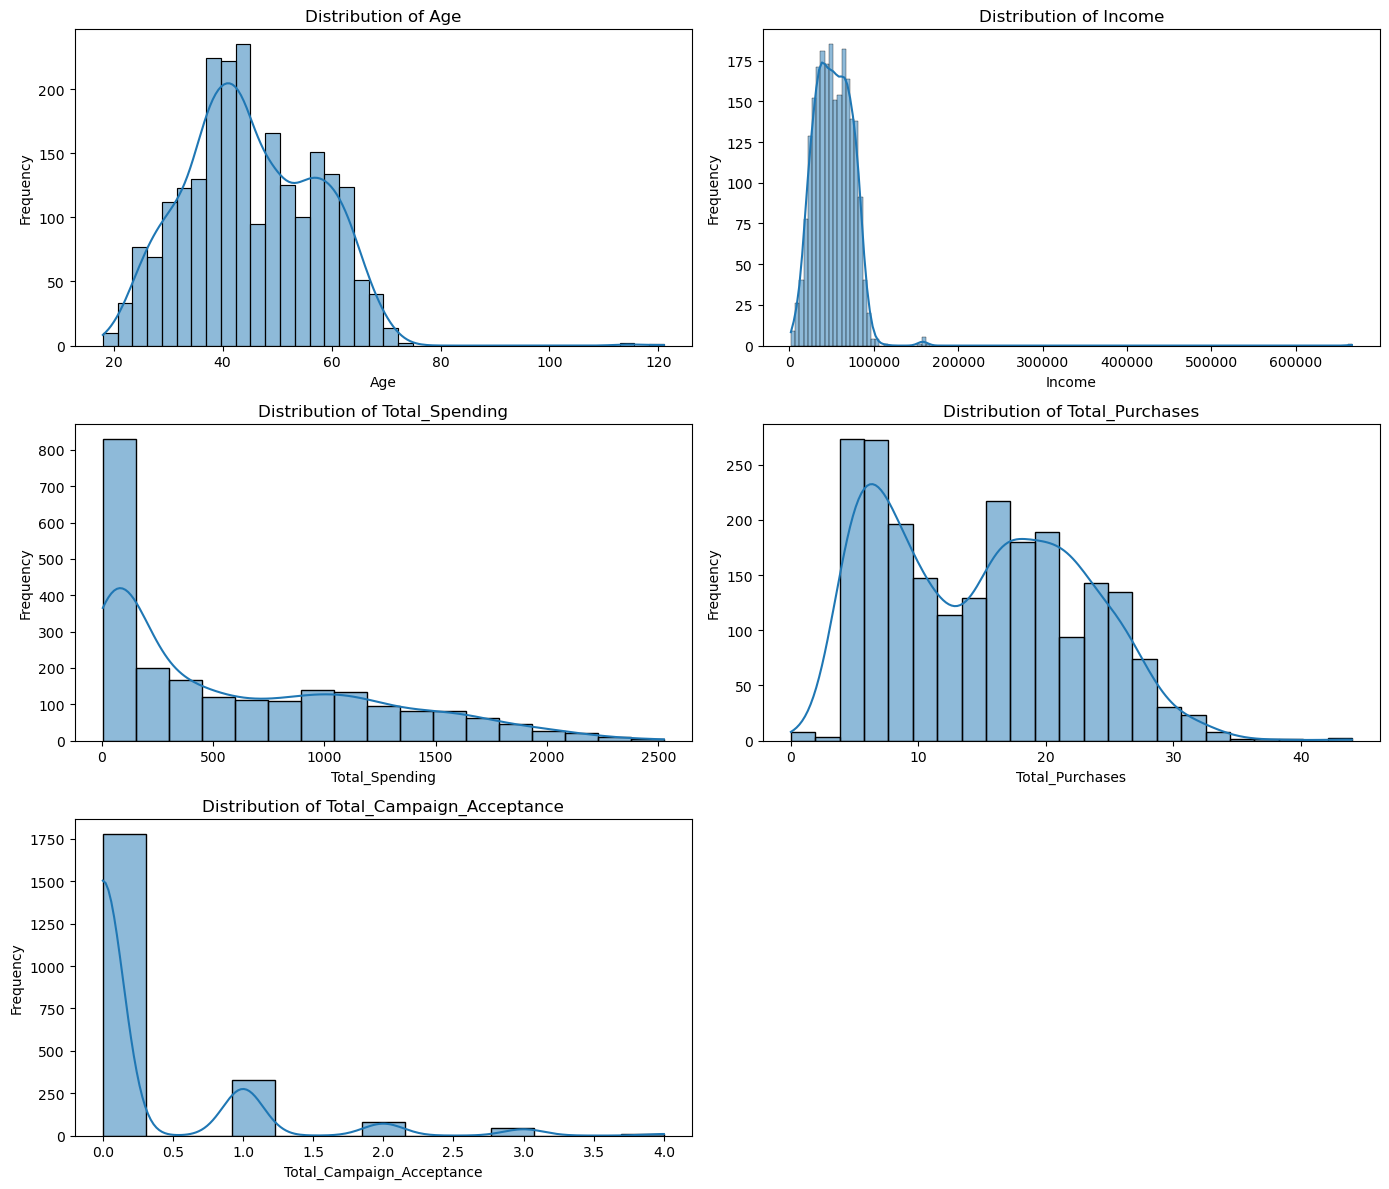

In [18]:
# Select important engineered features
eda_features = [
    "Age",
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Total_Campaign_Acceptance"
]

# Plot distributions
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for ax, column in zip(axes.flat, eda_features):
    sns.histplot(df_clean[column], kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

# Hide unused subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()

# Save figure
plt.savefig(r"customer_feature_distributions.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The distributions show that customer purchasing behavior is not uniform.

Income and total spending exhibit noticeable variation across customers, while purchase and campaign-response variables are concentrated around relatively low values.

The differences in feature scales and distributions indicate that feature scaling will be necessary before applying distance-based clustering algorithms such as K-Means.

### 5.2 Outlier Analysis

Boxplots are used to identify potential extreme observations in the main numerical customer features.

Outliers are not automatically removed because extreme customers may represent genuine high-value customers rather than data errors. Their influence will instead be considered during preprocessing and clustering.

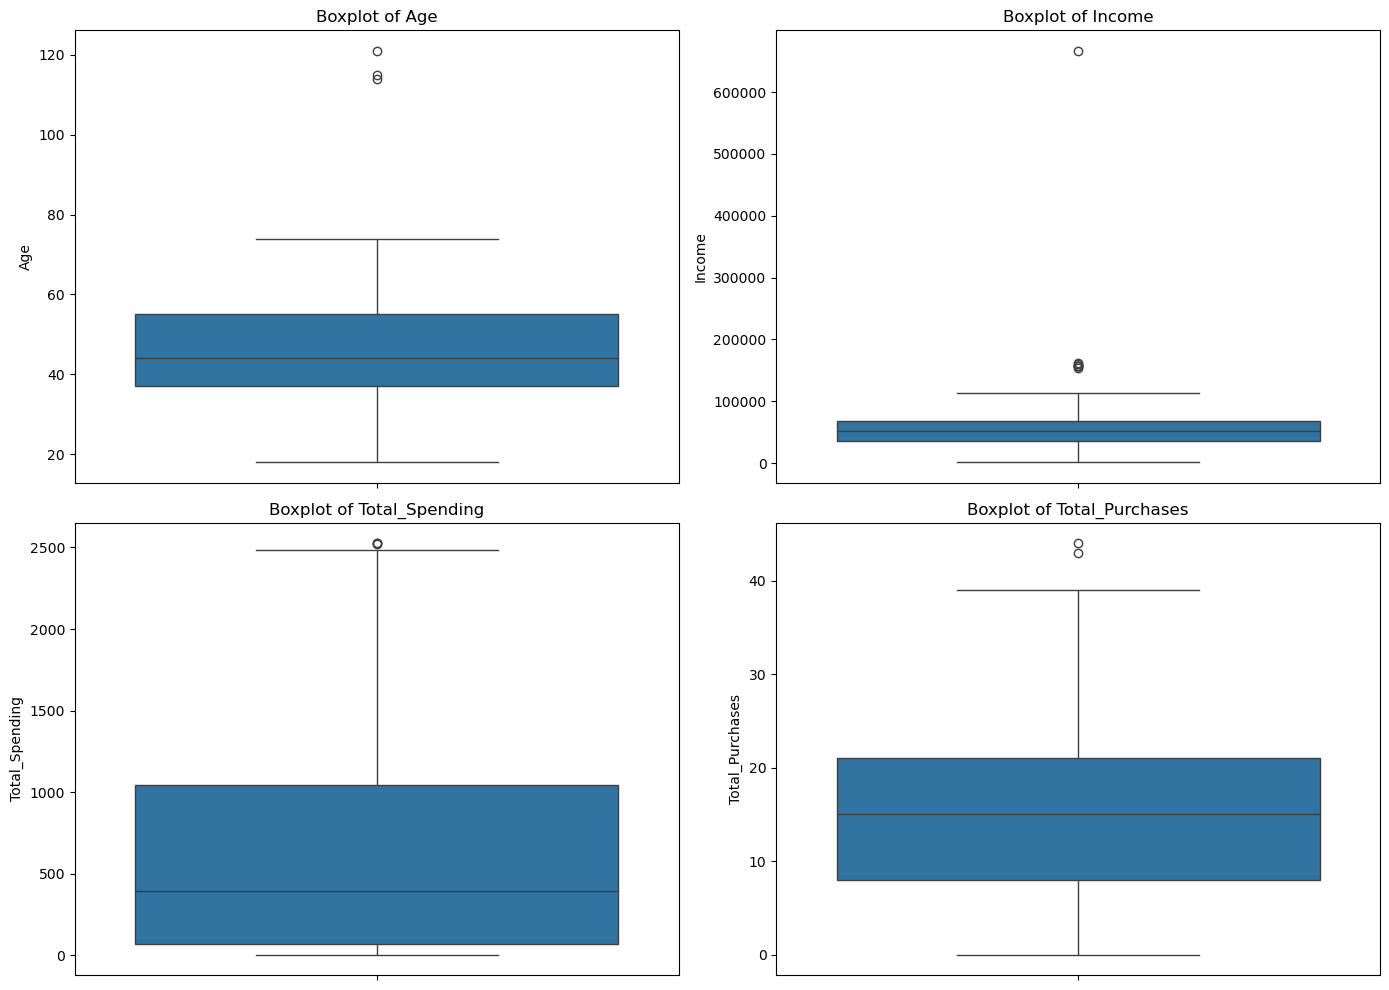

In [19]:
# Features for outlier analysis
outlier_features = [
    "Age",
    "Income",
    "Total_Spending",
    "Total_Purchases"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, column in zip(axes.flat, outlier_features):
    sns.boxplot(y=df_clean[column], ax=ax)
    ax.set_title(f"Boxplot of {column}")
    ax.set_ylabel(column)

plt.tight_layout()

# Save figure
plt.savefig(r"customer_feature_boxplots.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The boxplots indicate the presence of some extreme observations, particularly in income and spending-related variables.

These observations are not automatically treated as errors because they may represent genuine high-income or high-value customers.

Since K-Means uses distance calculations, the influence of extreme values will be controlled through appropriate preprocessing and scaling before clustering.

### 5.3 Correlation Analysis

A correlation matrix is generated to examine relationships among the major numerical customer features.

Correlation analysis helps identify strongly related variables and provides insight into customer demographic, purchasing, and engagement patterns.

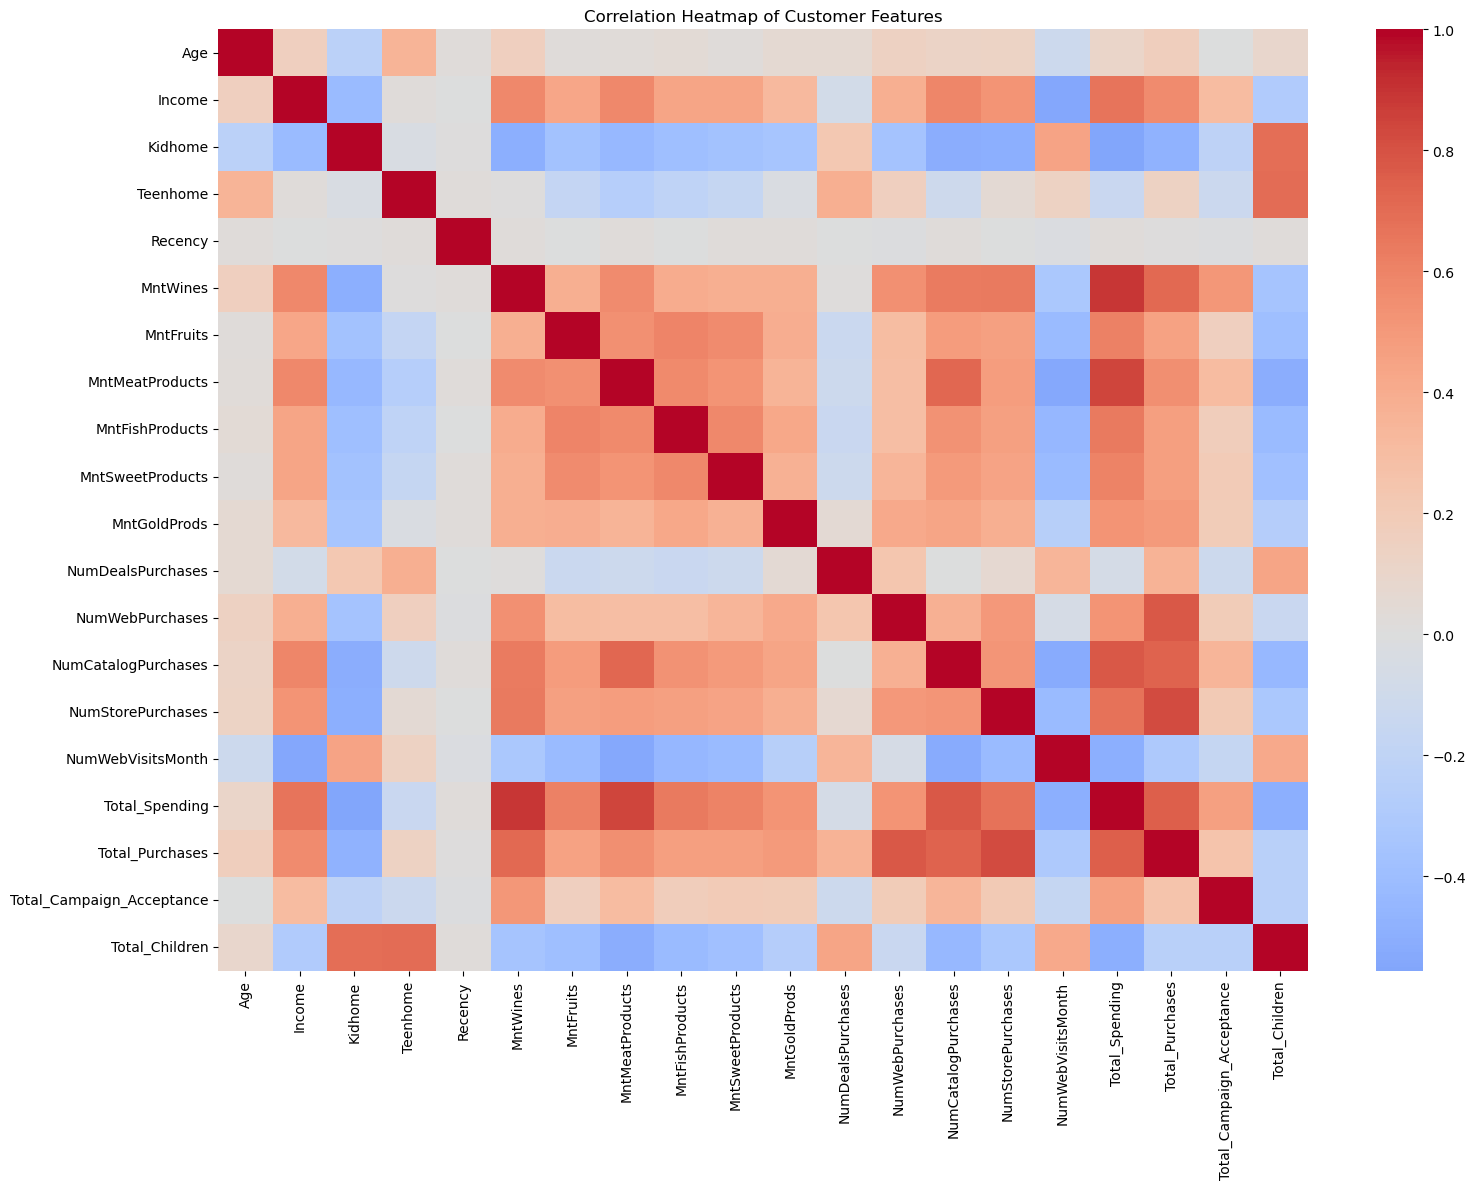

In [20]:
# Select numerical features for correlation analysis
correlation_features = [
    "Age",
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Total_Spending",
    "Total_Purchases",
    "Total_Campaign_Acceptance",
    "Total_Children"
]

correlation_matrix = df_clean[correlation_features].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Customer Features")
plt.tight_layout()

# Save figure
plt.savefig(r"customer_correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The correlation analysis shows that several spending variables are positively related to overall customer spending.

Similarly, the engineered `Total_Spending` and `Total_Purchases` variables summarize information from multiple underlying purchasing features.

These relationships are important for clustering because highly related variables can give certain aspects of customer behavior greater influence. Feature selection will therefore be considered before model training.

### 5.4 Income and Customer Spending

The relationship between customer income and total spending is examined to determine whether higher-income customers tend to generate greater purchasing value.

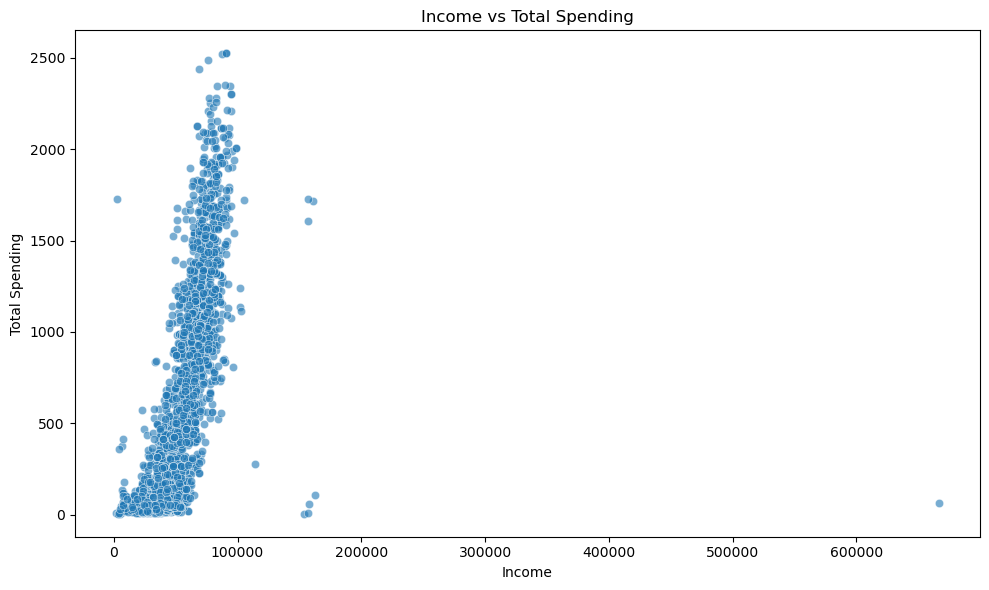

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="Income",
    y="Total_Spending",
    alpha=0.6
)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.tight_layout()

# Save figure
plt.savefig(r"income_vs_total_spending.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The scatter plot provides an overview of the relationship between customer income and spending behavior.

Although income may contribute to purchasing capacity, customer spending behavior is not determined by income alone. This supports the use of multiple behavioral and demographic variables when creating customer segments.

### 5.5 Customer Purchase Behavior

Customer purchases are distributed across deals, web, catalog, and store channels.

Examining these variables helps identify differences in purchasing behavior that may contribute to meaningful customer segments.

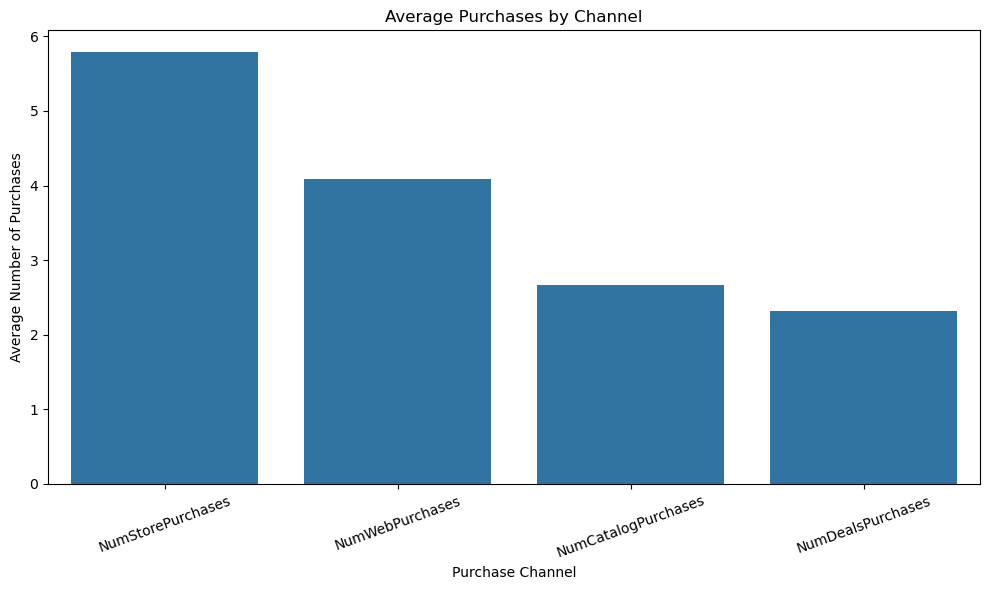

In [22]:
purchase_columns = [
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

purchase_means = df_clean[purchase_columns].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=purchase_means.index,
    y=purchase_means.values
)

plt.title("Average Purchases by Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Average Number of Purchases")
plt.xticks(rotation=20)

plt.tight_layout()

# Save figure
plt.savefig(r"average_purchases_by_channel.png", dpi=300, bbox_inches="tight")

plt.show()

### Overall EDA Findings

The exploratory analysis reveals substantial differences in customer demographics, spending, purchasing frequency, and campaign engagement.

Several variables show skewed distributions and potential extreme observations. The analysis also indicates strong relationships among some spending and purchasing variables.

Because the clustering algorithm will rely on distances between observations, the next stage will focus on categorical encoding, feature selection, and feature scaling.

The objective is to create a clean numerical feature matrix in which no individual variable dominates the clustering process solely because of its measurement scale.

## 6. Feature Selection and Preprocessing

K-Means clustering is based on distance calculations. Therefore, the quality of the resulting customer segments depends heavily on the features supplied to the algorithm.

The original dataset contains identifiers, demographic variables, purchasing behavior, campaign responses, and several derived features.

For clustering, variables that directly describe customer characteristics and behavior will be selected, while identifiers, constant variables, and redundant representations will be excluded.

The selected features will subsequently be transformed and standardized before applying K-Means clustering.

### 6.1 Selecting Customer Segmentation Features

The clustering feature set focuses on variables that represent meaningful differences in customer characteristics and behavior.

The selected variables capture:

- Demographic characteristics
- Customer recency
- Overall spending
- Purchase frequency and purchasing channels
- Website engagement
- Marketing campaign acceptance

This approach avoids using identifiers and constant variables while retaining information that can contribute to meaningful customer segments.

In [23]:
# Features selected for customer segmentation

clustering_features = [
    "Age",
    "Income",
    "Total_Children",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Total_Campaign_Acceptance"
]

X = df_clean[clustering_features].copy()

print("Number of clustering features:", len(clustering_features))
print("Clustering dataset shape:", X.shape)

display(X.head())

Number of clustering features: 12
Clustering dataset shape: (2240, 12)


,Age,Income,Total_Children,Recency,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Campaign_Acceptance
0,57,58138.0,0,58,1617,25,3,8,10,4,7,0
1,60,46344.0,2,38,27,6,2,1,1,2,5,0
2,49,71613.0,0,26,776,21,1,8,2,10,4,0
3,30,26646.0,1,26,53,8,2,2,0,4,6,0
4,33,58293.0,1,94,422,19,5,5,3,6,5,0


### 6.2 Validating the Selected Features

Before scaling the data, the selected feature matrix is checked for missing values and data types.

All clustering variables must be numerical and free from missing observations before they are passed to the clustering algorithm.

In [24]:
# Check missing values
print("Missing values:")
display(X.isnull().sum())

# Check data types
print("\nData types:")
display(X.dtypes)

Missing values:


Age                          0
Income                       0
Total_Children               0
Recency                      0
Total_Spending               0
Total_Purchases              0
NumDealsPurchases            0
NumWebPurchases              0
NumCatalogPurchases          0
NumStorePurchases            0
NumWebVisitsMonth            0
Total_Campaign_Acceptance    0
dtype: int64


Data types:


Age                            int64
Income                       float64
Total_Children                 int64
Recency                        int64
Total_Spending                 int64
Total_Purchases                int64
NumDealsPurchases              int64
NumWebPurchases                int64
NumCatalogPurchases            int64
NumStorePurchases              int64
NumWebVisitsMonth              int64
Total_Campaign_Acceptance      int64
dtype: object

### 6.3 Comparing Feature Scales

The selected variables have substantially different numerical ranges.

For example, income may contain values in the tens of thousands, while campaign acceptance and the number of children have much smaller ranges.

Because K-Means uses distance calculations, variables with larger numerical scales could dominate the clustering process.

Therefore, feature standardization will be performed before model training.

In [25]:
# Display descriptive statistics of selected features
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,2240.0,45.194196,11.984069,18.0,37.00,44.0,55.00,121.0
Income,2240.0,52237.975446,25037.955891,1730.0,35538.75,51381.5,68289.75,666666.0
Total_Children,2240.0,0.950446,0.751803,0.0,0.00,1.0,1.00,3.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
Total_Spending,2240.0,605.798214,602.249288,5.0,68.75,396.0,1045.50,2525.0
Total_Purchases,2240.0,14.862054,7.677173,0.0,8.00,15.0,21.00,44.0
NumDealsPurchases,2240.0,2.325000,1.932238,0.0,1.00,2.0,3.00,15.0
NumWebPurchases,2240.0,4.084821,2.778714,0.0,2.00,4.0,6.00,27.0
NumCatalogPurchases,2240.0,2.662054,2.923101,0.0,0.00,2.0,4.00,28.0
NumStorePurchases,2240.0,5.790179,3.250958,0.0,3.00,5.0,8.00,13.0


## 7. Feature Standardization

K-Means clustering calculates distances between observations.

To prevent variables with larger numerical ranges from dominating the distance calculations, the selected features are standardized using `StandardScaler`.

Standardization transforms each feature so that it has approximately:

- Mean = 0
- Standard deviation = 1

This ensures that the clustering algorithm gives each feature a more comparable influence based on its standardized variation rather than its original measurement scale.

In [26]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Standardize selected features
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (2240, 12)


### 7.1 Verifying Standardization

The standardized dataset is converted back into a DataFrame so that the resulting feature means and standard deviations can be inspected.

The feature means should be approximately zero and the standard deviations should be approximately one.

In [27]:
# Convert scaled array back to DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

# Check mean and standard deviation
scaling_check = pd.DataFrame({
    "Mean": X_scaled_df.mean(),
    "Standard_Deviation": X_scaled_df.std()
})

display(scaling_check)

,Mean,Standard_Deviation
Age,-1.681195e-16,1.000223
Income,-4.361590e-17,1.000223
Total_Children,4.123686e-17,1.000223
Recency,-3.172066e-18,1.000223
Total_Spending,3.647876e-17,1.000223
Total_Purchases,-1.110223e-17,1.000223
NumDealsPurchases,-9.833404e-17,1.000223
NumWebPurchases,-5.709718e-17,1.000223
NumCatalogPurchases,9.516197e-18,1.000223
NumStorePurchases,7.612958e-17,1.000223


### 7.2 Effect of Standardization

The distributions of selected variables are compared before and after standardization.

This visualization demonstrates how standardization places the features on a comparable scale while preserving their relative distribution patterns.

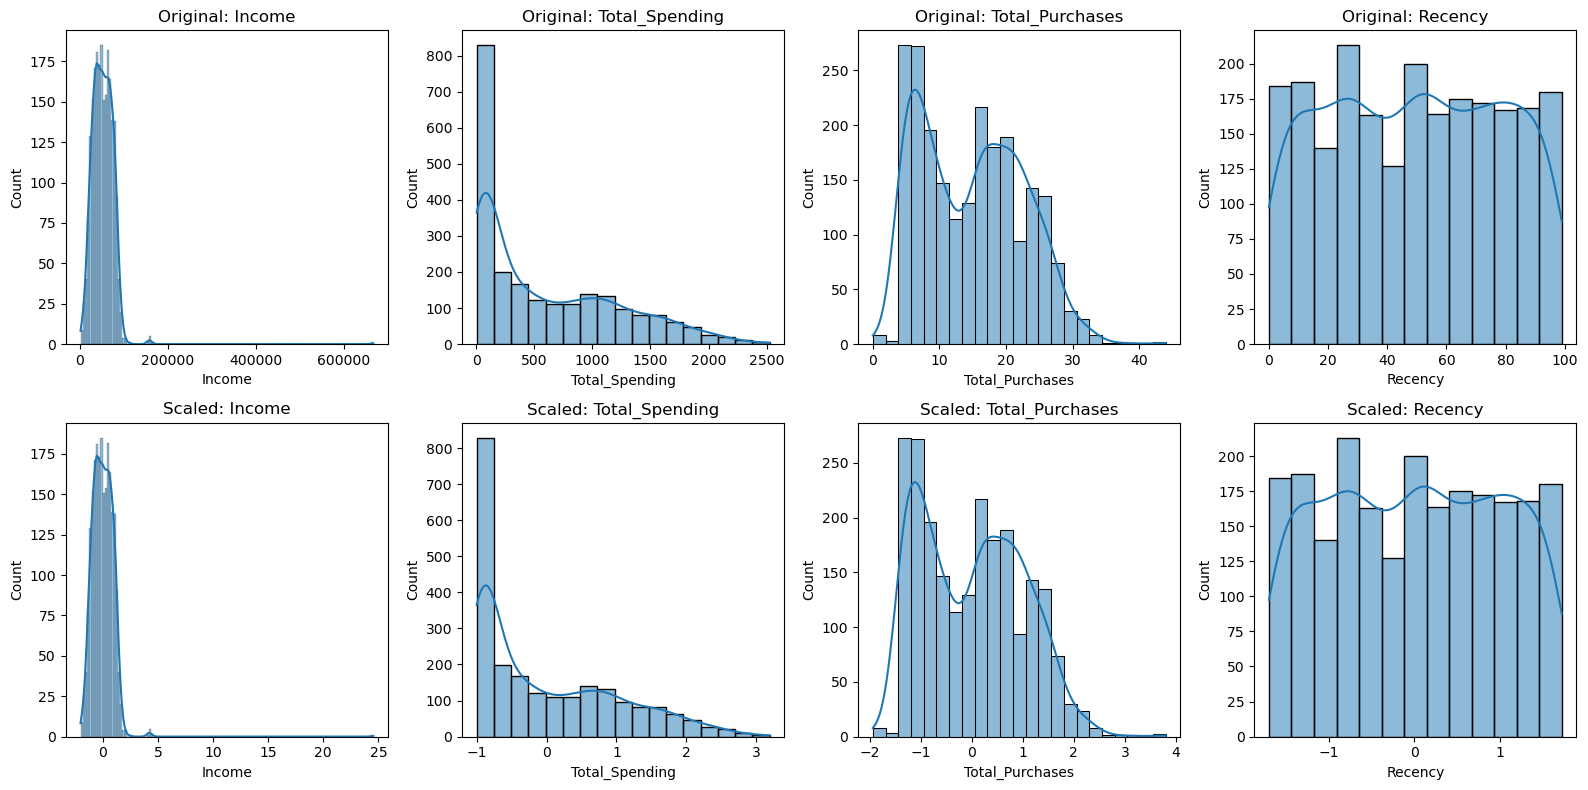

In [28]:
# Select a few representative features
comparison_features = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Recency"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, column in enumerate(comparison_features):

    # Original feature
    sns.histplot(
        X[column],
        kde=True,
        ax=axes[0, i]
    )

    axes[0, i].set_title(f"Original: {column}")

    # Scaled feature
    sns.histplot(
        X_scaled_df[column],
        kde=True,
        ax=axes[1, i]
    )

    axes[1, i].set_title(f"Scaled: {column}")

plt.tight_layout()

# Save figure
plt.savefig(r"before_after_standardization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The standardization process changes the numerical scale of the selected variables while preserving their underlying distribution patterns.

After standardization, the features are centered around zero and have comparable standard deviations.

The resulting standardized feature matrix is therefore suitable for distance-based clustering algorithms such as K-Means.

## 8. Determining the Optimal Number of Clusters

The appropriate number of customer segments is not known in advance.

The Elbow Method is first used to evaluate different values of K.

For each value of K, K-Means is fitted and the Within-Cluster Sum of Squares (WCSS), also known as inertia, is recorded.

A noticeable reduction in the rate of improvement can indicate a suitable number of clusters.

C:\Users\saifia computers\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\saifia computers\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\saifia computers\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\saifia computers\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\saifia computers\anaconda3\Lib\subprocess.py", line 1538, in 

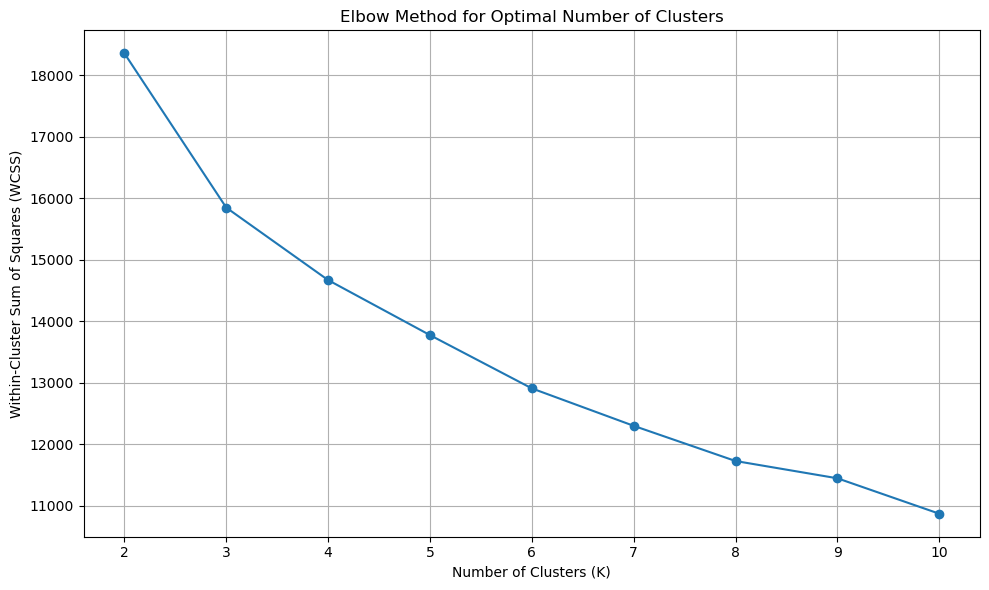

In [29]:
from sklearn.cluster import KMeans

# Calculate inertia for different numbers of clusters
inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(k_values)

plt.grid(True)

plt.tight_layout()

# Save figure
plt.savefig(r"elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Elbow Method Observation

The elbow curve shows how within-cluster variation decreases as the number of clusters increases.

Although increasing K always reduces within-cluster variation, the goal is to identify a point where additional clusters provide progressively smaller improvements.

The Elbow Method will be considered together with the Silhouette Score before selecting the final number of customer segments.

### 8.1 Silhouette Score Analysis

The Silhouette Score evaluates how well each observation fits within its assigned cluster compared with other clusters.

Scores closer to 1 indicate well-separated and internally consistent clusters, while values near 0 indicate overlapping clusters.

Silhouette scores are calculated for K values from 2 to 10 and will be used alongside the Elbow Method to select the final clustering configuration.

In [30]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

# Create results table
silhouette_results = pd.DataFrame({
    "Number_of_Clusters": range(2, 11),
    "Silhouette_Score": silhouette_scores
})

display(silhouette_results)

,Number_of_Clusters,Silhouette_Score
0,2,0.304260
1,3,0.256991
2,4,0.258842
3,5,0.169852
4,6,0.163097
5,7,0.165670
6,8,0.166621
7,9,0.144618
8,10,0.146139


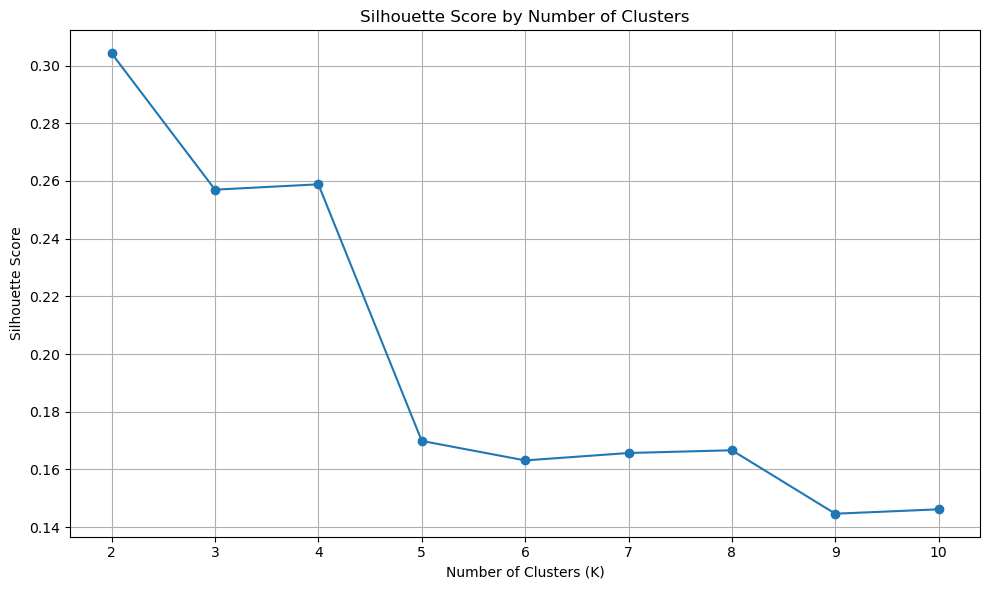

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    silhouette_results["Number_of_Clusters"],
    silhouette_results["Silhouette_Score"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2, 11))
plt.grid(True)

plt.tight_layout()

# Save figure
plt.savefig(r"silhouette_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Final K-Means Clustering

Based on the cluster evaluation performed using the Elbow Method and Silhouette Analysis, **K = 2** is selected as the optimal number of clusters.

The Silhouette Score achieved its highest value at K = 2, indicating that this configuration provides the best cluster separation among the tested values.

A final K-Means model is therefore trained using two clusters.

In [32]:
# Train the final K-Means model

optimal_k = 2

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

print(f"Optimal number of clusters: {optimal_k}")
print(f"Final model inertia: {kmeans_final.inertia_:.2f}")

Optimal number of clusters: 2
Final model inertia: 18359.83


### Assigning Cluster Labels

The cluster labels generated by the final K-Means model are assigned to the prepared customer dataset.

Each customer is therefore classified into one of the two identified customer segments.

In [33]:
# Add cluster labels to the dataset

X_clustered = X.copy()
X_clustered["Cluster"] = cluster_labels

display(X_clustered.head())

,Age,Income,Total_Children,Recency,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Campaign_Acceptance,Cluster
0,57,58138.0,0,58,1617,25,3,8,10,4,7,0,1
1,60,46344.0,2,38,27,6,2,1,1,2,5,0,0
2,49,71613.0,0,26,776,21,1,8,2,10,4,0,1
3,30,26646.0,1,26,53,8,2,2,0,4,6,0,0
4,33,58293.0,1,94,422,19,5,5,3,6,5,0,1


### Cluster Size Distribution

The number of customers assigned to each cluster is examined to understand the distribution of customers across the identified segments.

In [34]:
# Count customers in each cluster

cluster_counts = X_clustered["Cluster"].value_counts().sort_index()

print("Number of customers in each cluster:")
display(cluster_counts)

Number of customers in each cluster:


Cluster
0    1194
1    1046
Name: count, dtype: int64

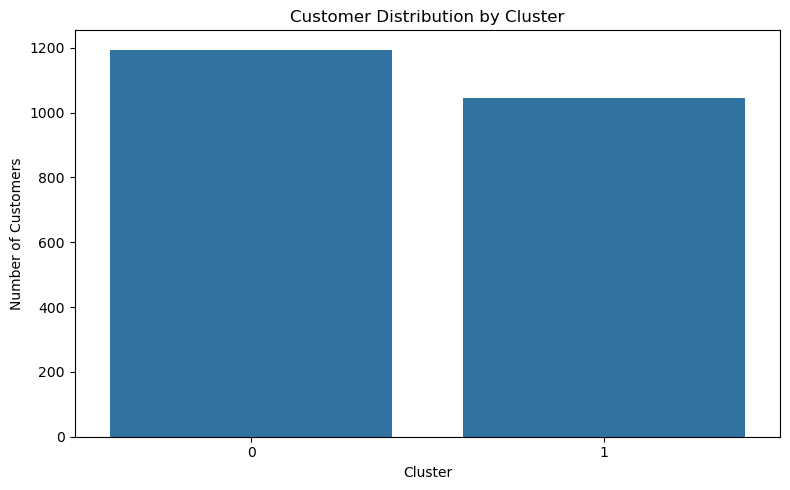

In [35]:
# Visualize cluster sizes

plt.figure(figsize=(8, 5))

sns.countplot(
    x="Cluster",
    data=X_clustered
)

plt.title("Customer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(r"cluster_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 10. Cluster Profiling and Business Interpretation

After assigning customers to their respective clusters, the next step is to profile each customer segment.

Cluster profiling helps identify the key demographic, purchasing, and engagement characteristics of each segment. By comparing the average values of important features across clusters, meaningful customer patterns can be identified.

The purpose of this analysis is not only to create mathematical clusters but also to translate the clustering results into meaningful business insights.

## 10.1 Cluster Size Analysis

The number of customers in each cluster is examined to understand the distribution of customers across the identified segments.

In [36]:
# Create a copy of the original dataset and add the final cluster labels

df_clustered = df.copy()

df_clustered["Cluster"] = cluster_labels

print("Cluster labels added successfully.")
print("\nNumber of customers in each cluster:")

cluster_counts = df_clustered["Cluster"].value_counts().sort_index()

display(cluster_counts)

Cluster labels added successfully.

Number of customers in each cluster:


Cluster
0    1194
1    1046
Name: count, dtype: int64

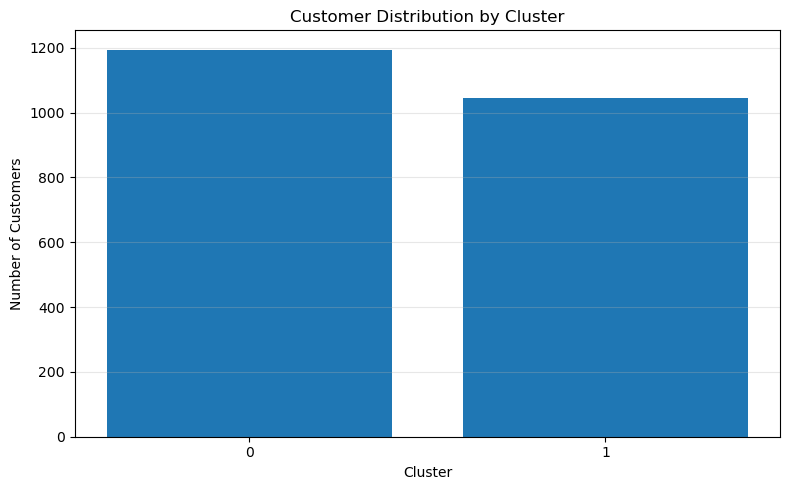

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Customer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    r"cluster_size_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10.2 Cluster Profile

The average values of the selected features are calculated for each cluster to identify the characteristics that distinguish the customer segments.

This analysis compares demographic, purchasing, campaign-response, and engagement-related variables across the identified clusters.

In [38]:
print("Comparison features:")
print(comparison_features)

Comparison features:
['Income', 'Total_Spending', 'Total_Purchases', 'Recency']


In [39]:
comparison_features = [
    "Income",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

print("Comparison features updated successfully.")
print(comparison_features)

Comparison features updated successfully.
['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']


In [40]:
cluster_profile = df_clustered.groupby("Cluster")[comparison_features].mean()

display(cluster_profile)

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
Cluster,,,,,,,,,,,,,,,,,,,
0,36576.650255,49.101340,65.374372,5.747906,31.094640,8.737856,5.984087,19.971524,2.299832,2.520938,0.69598,3.498325,6.463987,0.001675,0.001675,0.067839,0.018425,0.000000,0.093802
1,70031.421002,49.118547,576.251434,49.764818,322.027725,70.386233,51.124283,71.475143,2.353728,5.869981,4.90631,8.406310,4.006692,0.135755,0.026769,0.078394,0.138623,0.155832,0.212237


In [41]:
display(cluster_profile.T)

Cluster,0,1
Income,36576.650255,70031.421002
Recency,49.101340,49.118547
MntWines,65.374372,576.251434
MntFruits,5.747906,49.764818
MntMeatProducts,31.094640,322.027725
MntFishProducts,8.737856,70.386233
MntSweetProducts,5.984087,51.124283
MntGoldProds,19.971524,71.475143
NumDealsPurchases,2.299832,2.353728
NumWebPurchases,2.520938,5.869981


## 10.3 Key Differences Between Clusters

The cluster profiles reveal substantial differences between the two customer segments.

Cluster 0 contains customers with lower average income and considerably lower purchasing and spending levels across the product categories. These customers also have a higher average number of monthly website visits but relatively fewer purchases.

Cluster 1 contains customers with substantially higher average income, spending, and purchasing activity. They also show stronger responses to previous marketing campaigns and higher purchasing activity across web, catalog, and store channels.

Recency is relatively similar between the two clusters, indicating that the primary differences between the segments are related to customer value, purchasing behavior, and campaign responsiveness rather than recent purchase timing.

## 10.4 Standardized Cluster Profile

To make variables with different numerical scales comparable, the cluster-level averages are standardized before visualization.

This allows the relative strengths and weaknesses of each customer segment to be compared across income, spending, purchasing activity, website engagement, and campaign response.

In [42]:
# Standardize cluster profile values for comparison

from sklearn.preprocessing import StandardScaler

profile_scaler = StandardScaler()

cluster_profile_scaled = pd.DataFrame(
    profile_scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

display(cluster_profile_scaled)

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
Cluster,,,,,,,,,,,,,,,,,,,
0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0


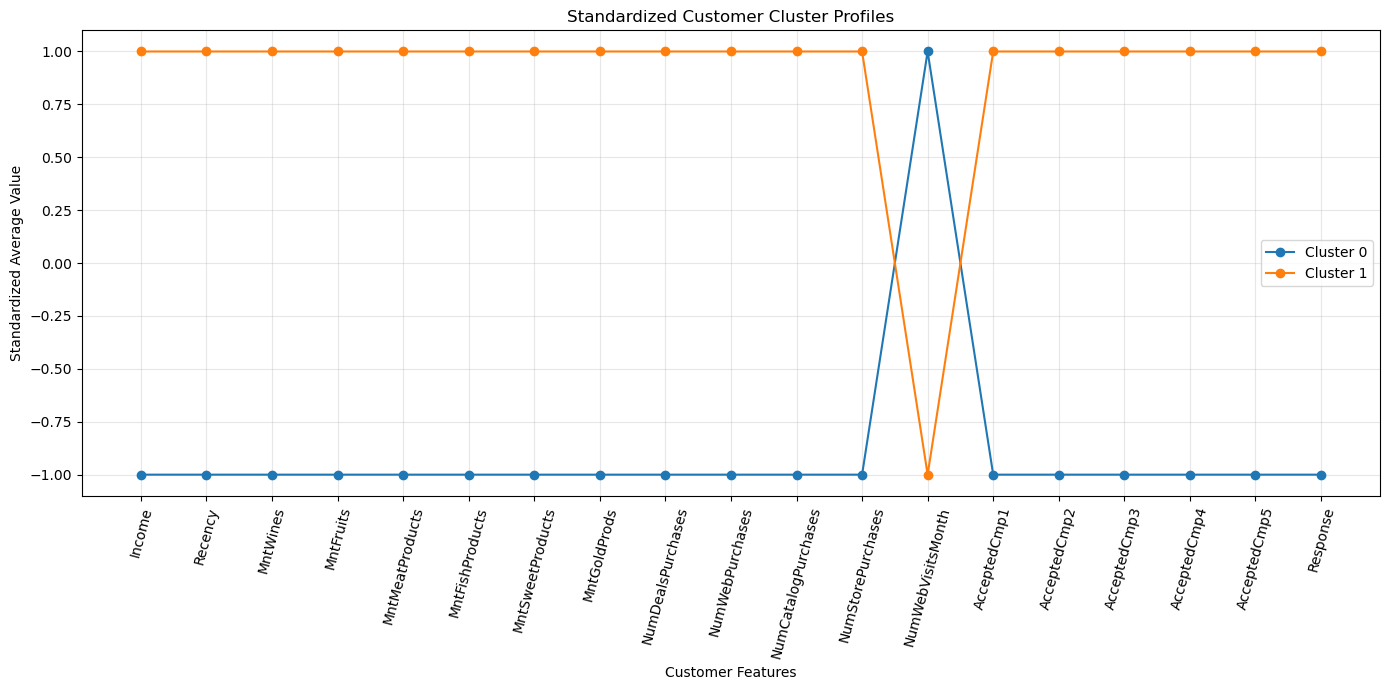

In [43]:
plt.figure(figsize=(14, 7))

plt.plot(
    cluster_profile_scaled.columns,
    cluster_profile_scaled.loc[0],
    marker="o",
    label="Cluster 0"
)

plt.plot(
    cluster_profile_scaled.columns,
    cluster_profile_scaled.loc[1],
    marker="o",
    label="Cluster 1"
)

plt.title("Standardized Customer Cluster Profiles")
plt.xlabel("Customer Features")
plt.ylabel("Standardized Average Value")
plt.xticks(rotation=75)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    r"cluster_profile_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10.5 Business Interpretation

### Cluster 0 — Lower-Value / Less Active Customers

Cluster 0 represents customers with comparatively lower income, spending, and purchasing activity.

Their average spending across all major product categories is substantially lower than Cluster 1. They also make fewer web, catalog, and store purchases.

Interestingly, Cluster 0 has a higher average number of website visits per month. This suggests that these customers may show interest or browse the website without converting that engagement into purchases at the same level as Cluster 1.

From a business perspective, this segment may benefit from targeted promotions, personalized recommendations, introductory offers, and conversion-focused campaigns.


### Cluster 1 — Higher-Value / Highly Active Customers

Cluster 1 represents customers with substantially higher income and purchasing activity.

Their average spending is considerably higher across wine, fruits, meat, fish, sweet products, and gold products. They also make more purchases through web, catalog, and store channels.

Cluster 1 additionally shows stronger responses to previous marketing campaigns and a higher overall response rate.

This segment represents a higher-value customer group and may be suitable for loyalty programs, premium product recommendations, personalized campaigns, and retention strategies.


### Overall Business Insight

The K-Means model successfully separates customers primarily according to differences in customer value, purchasing behavior, and marketing responsiveness.

The two clusters therefore provide a useful basis for differentiated customer-marketing strategies rather than treating the entire customer base as a single group.

## 10.6 Customer Segment Summary

The following summary consolidates the main characteristics and potential business strategies associated with each identified customer segment.

In [44]:
# Create a concise business summary of the customer segments

segment_summary = pd.DataFrame({
    "Cluster": ["Cluster 0", "Cluster 1"],
    "Customer_Count": [
        cluster_counts.loc[0],
        cluster_counts.loc[1]
    ],
    "Segment_Profile": [
        "Lower-value / less active customers",
        "Higher-value / highly active customers"
    ],
    "Recommended_Strategy": [
        "Conversion-focused offers and personalized promotions",
        "Retention, loyalty, and premium customer strategies"
    ]
})

display(segment_summary)

,Cluster,Customer_Count,Segment_Profile,Recommended_Strategy
0,Cluster 0,1194,Lower-value / less active customers,Conversion-focused offers and personalized pro...
1,Cluster 1,1046,Higher-value / highly active customers,"Retention, loyalty, and premium customer strat..."


### Section 10 Summary

The cluster profiling analysis identified two meaningful customer segments.

**Cluster 0** consists primarily of lower-value customers with lower spending and purchasing activity, despite relatively higher website visits.

**Cluster 1** consists of higher-value customers characterized by substantially higher income, product spending, purchase frequency, and marketing response.

These differences demonstrate that the clustering model provides actionable customer segmentation that can support differentiated marketing and customer-retention strategies.

# 11. Final Cluster Visualization

The final customer segments are visualized to provide a graphical representation of the clustering results.

Because the dataset contains multiple features, Principal Component Analysis (PCA) is used to reduce the feature space to two dimensions. The resulting visualization provides an intuitive view of how the customer observations are distributed according to their assigned clusters.

## 11.1 PCA Cluster Visualization

Principal Component Analysis reduces the standardized customer features to two principal components while preserving as much of the variation in the original data as possible.

The two-dimensional representation is used only for visualization; the actual K-Means clustering was performed using the full standardized feature set.

In [45]:
# Apply PCA to reduce the standardized feature space to two dimensions

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels

print("Explained variance ratio:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))

print(
    "Total explained variance:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

Explained variance ratio:
PC1: 0.3996
PC2: 0.1559
Total explained variance: 0.5554


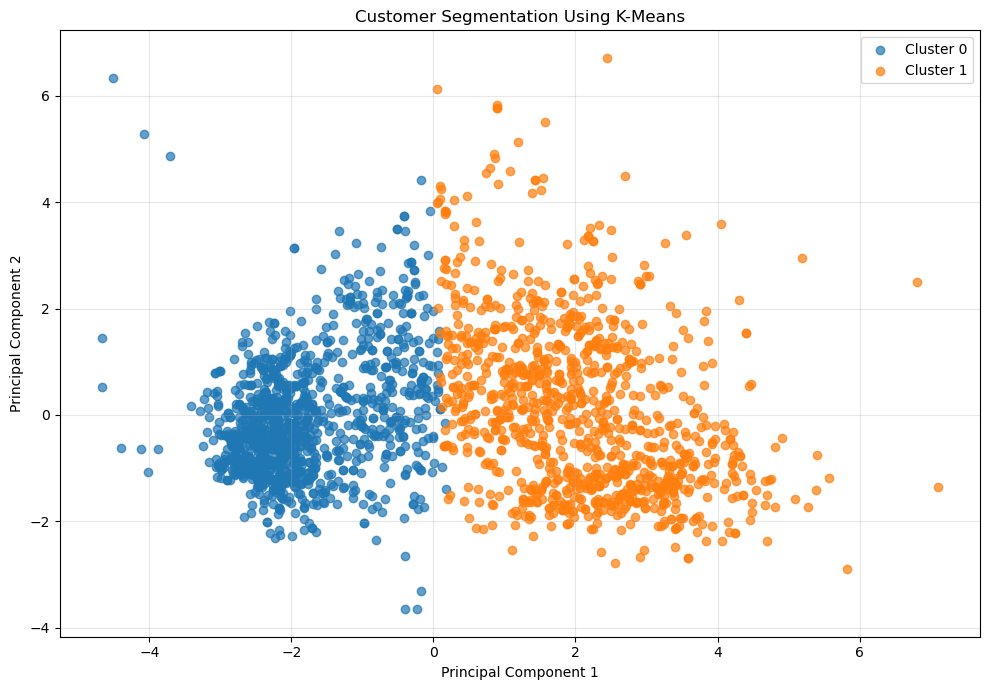

In [46]:
plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["Cluster"].unique()):
    
    cluster_data = pca_df[pca_df["Cluster"] == cluster]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.title("Customer Segmentation Using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    r"final_customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The PCA visualization provides a two-dimensional representation of the customer segments generated by K-Means clustering.

The two clusters can be visually compared according to their positions in the reduced feature space. Because PCA is a dimensionality-reduction technique, some overlap between clusters is expected and does not necessarily indicate an error in the clustering model.

The visualization complements the numerical cluster profiling performed earlier and provides an intuitive representation of the segmentation results.

## 11.2 Income and Spending by Customer Segment

Income and product spending are important indicators of customer value.

A scatter plot is used to compare customer income and total product spending while distinguishing customers according to their assigned cluster.

In [47]:
# Calculate total product spending

spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df_clustered["Total_Spending"] = df_clustered[spending_columns].sum(axis=1)

display(
    df_clustered[
        ["Income", "Total_Spending", "Cluster"]
    ].head()
)

,Income,Total_Spending,Cluster
0,58138.0,1617,1
1,46344.0,27,0
2,71613.0,776,1
3,26646.0,53,0
4,58293.0,422,1


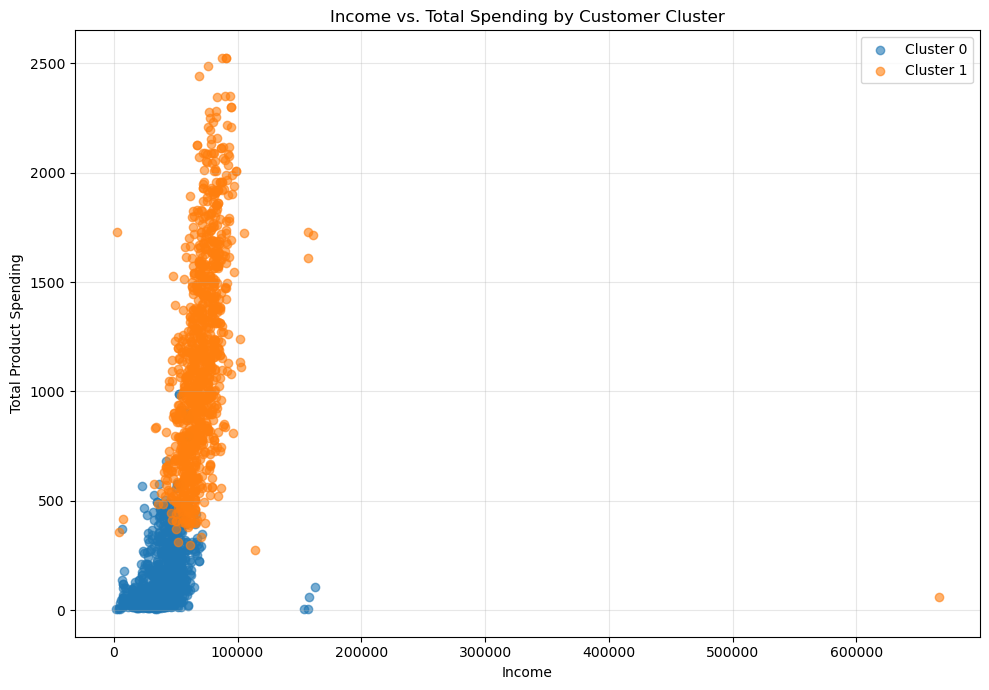

In [48]:
plt.figure(figsize=(10, 7))

for cluster in sorted(df_clustered["Cluster"].unique()):
    
    cluster_data = df_clustered[
        df_clustered["Cluster"] == cluster
    ]
    
    plt.scatter(
        cluster_data["Income"],
        cluster_data["Total_Spending"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.title("Income vs. Total Spending by Customer Cluster")
plt.xlabel("Income")
plt.ylabel("Total Product Spending")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    r"income_vs_spending_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The income-versus-spending visualization provides a business-oriented view of the customer segments.

The plot helps illustrate the relationship between customer income and total product spending while showing the cluster assignment of individual customers.

This visualization complements the numerical cluster profile, where Cluster 1 showed substantially higher average income and product spending than Cluster 0.

# 12. Final Findings and Conclusion

This project applied an unsupervised machine-learning approach to segment customers according to demographic characteristics, purchasing behavior, campaign responses, and engagement-related variables.

The analysis followed a complete customer-segmentation workflow including data inspection, data cleaning, exploratory analysis, feature preparation, standardization, K-Means clustering, cluster evaluation, cluster profiling, visualization, and business interpretation.

The Elbow Method and Silhouette Score were used to evaluate the appropriate number of clusters. The highest Silhouette Score was obtained at **K = 2**, supporting the selection of two customer segments for the final K-Means model.

The final model divided the 2,240 customers into:

- **Cluster 0:** 1,194 customers
- **Cluster 1:** 1,046 customers

Cluster profiling showed substantial differences between the two groups. Cluster 1 demonstrated considerably higher average income, product spending, purchasing activity, and campaign response. Cluster 0 demonstrated lower purchasing and spending levels while having a higher average number of monthly website visits.

These findings suggest that the customer base can be differentiated into meaningful segments with different behavioral and commercial characteristics.

From a business perspective, the lower-value segment can be targeted with conversion-focused promotions and personalized offers, while the higher-value segment can be approached through retention strategies, loyalty programs, and premium or personalized marketing campaigns.

Overall, the project demonstrates how K-Means clustering can transform customer-level data into actionable customer segments that can support data-driven marketing and customer-management decisions.

## 12.1 Exporting the Final Segmented Dataset

The final customer dataset is exported as a CSV file containing the original customer information, engineered spending information, and final cluster assignments.

This file represents the main output of the customer-segmentation project and can be reused for further analysis or business reporting.

In [49]:
# Save the final customer segmentation dataset

df_clustered.to_csv(
    r"customer_segmented.csv",
    index=False
)

print("Final segmented dataset saved successfully.")
print("Rows:", df_clustered.shape[0])
print("Columns:", df_clustered.shape[1])

Final segmented dataset saved successfully.
Rows: 2240
Columns: 31


## 12.3 Final Data Validation

Before completing the project, the final dataset is checked to ensure that cluster assignments are present and that the exported dataset contains the expected records.

In [50]:
# Final validation

print("Final dataset shape:", df_clustered.shape)

print("\nMissing values in final dataset:")
display(df_clustered.isnull().sum()[df_clustered.isnull().sum() > 0])

print("\nCluster distribution:")
display(df_clustered["Cluster"].value_counts().sort_index())

print("\nFinal dataset preview:")
display(df_clustered.head())

Final dataset shape: (2240, 31)

Missing values in final dataset:


Income    24
dtype: int64


Cluster distribution:


Cluster
0    1194
1    1046
Name: count, dtype: int64


Final dataset preview:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Cluster,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,1,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,0,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,1,776
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,0,53
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,1,422
